# 01 · Who should we email? — customer-level uplift  ⭐ ANCHOR A

**The decision.** We have a €10 discount and a customer list. Emailing everyone
burns margin on people who'd have bought anyway (and annoys some into leaving).
Emailing no one leaves money on the table. **Who, exactly, should get the offer?**

The right target is the *persuadables* — customers whose behaviour actually
**changes** because of the email — not the "sure things" (buy regardless) or the
"lost causes" (won't buy regardless). That per-customer *change* is a causal
quantity, and estimating it well is the whole game of uplift/HTE modelling.

This is the flagship notebook. It follows the fixed 7-step contract used
everywhere in this repo, and then adds the **three depths** that a data scientist
needs to defend the number:

1. **Business question** → 2. **Simulate a known truth** → 3. **Identify** →
4. **Estimate** → 5. **Validate** → 6. **Decide, in euros** → 7. **Caveats**
   *…then…*
   **Depth A** estimator bake-off & failure modes · **Depth B** identification
   rigour & sensitivity · **Depth C** euro policy with sweeps & value-of-information.

> Narration is business-first. "Bayesian" stays in the background; credible
> intervals show up as *"how sure are we, and does it change what we'd do?"*


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings("ignore")

from cmp import dgp, estimators as est, metrics, policy, plots
plots.use_style()

# FAST=1 (default) -> few draws/trees for CI & live reruns (< ~2 min).
# FAST=0 -> full-quality run that reproduces the reference figures.
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 7
COST = 8.0                      # € cost of one discount contact
N    = 800 if FAST else 1400
PROF = dict(draws=120, tune=120, chains=2, m=30) if FAST else dict(draws=500, tune=500, chains=4, m=100)
print(f"FAST={FAST}  N={N}  sampling={PROF}")

FAST=True  N=800  sampling={'draws': 120, 'tune': 120, 'chains': 2, 'm': 30}


## 2 · Simulate a ground truth (validation-first)

Before trusting a method on real data, we make it prove itself on data where we
**know the answer**. Our simulator plants a known per-customer effect `τ(x)` and
a known baseline spend, then generates observed spend. Because we know `τ(x)`, we
can later check the method *recovers* it.

The planted effect is deliberately realistic and **heterogeneous**:

- **Persuadables** — moderately-recent, engaged, mid-frequency customers — get a
  large positive lift (the email tips them over).
- **Sleeping dogs** — low-engagement, high-frequency customers — get a *negative*
  effect (the email nudges a habitual buyer to unsubscribe/churn).
- Everyone else sits near zero.

We use the **observational** regime: historically, marketers mailed the already-
engaged and recently-active customers, so treatment is *confounded* with the kind
of customer. That's the realistic and harder case — exactly where naive maths
misleads. (`regime="randomized"` is available for the clean A/B case, used in
Depth A.)

> **Swap in real data here.** Replace this cell with a loader that returns the
> same columns (see `cmp.data.load_hillstrom` for a real randomized email set).


In [2]:
df = dgp.uplift_customers(n=N, regime="observational", confounder_strength=0.0, cost=COST, seed=SEED)
feat = df.attrs["feature_cols"]
X, T, y, tau = df[feat].values, df["T"].values, df["y"].values, df["tau"].values

print(f"True ATE (avg effect)      €{tau.mean():.2f}")
print(f"Treated (emailed) share    {T.mean():.0%}")
print(f"Persuadables (τ > €{COST})  {(tau > COST).mean():.0%} of the base")
print(f"Sleeping dogs (τ < 0)      {(tau < 0).mean():.0%} of the base")
df[feat + ['T','y','tau']].head()

True ATE (avg effect)      €5.87
Treated (emailed) share    46%
Persuadables (τ > €8.0)  32% of the base
Sleeping dogs (τ < 0)      29% of the base


,recency,frequency,monetary,tenure,engage,T,y,tau
0,208.156027,8.0,103.496170,17.049224,0.183294,1.0,32.371738,-10.281553
1,296.594485,9.0,75.826833,41.973450,0.480901,0.0,52.119931,-1.975536
2,257.097849,2.0,126.634466,43.702896,0.284999,0.0,48.483094,0.054543
3,78.192337,6.0,138.026176,35.941652,0.586388,1.0,97.646079,25.905900
4,102.554043,5.0,58.762566,51.889769,0.252452,0.0,39.578661,12.863950


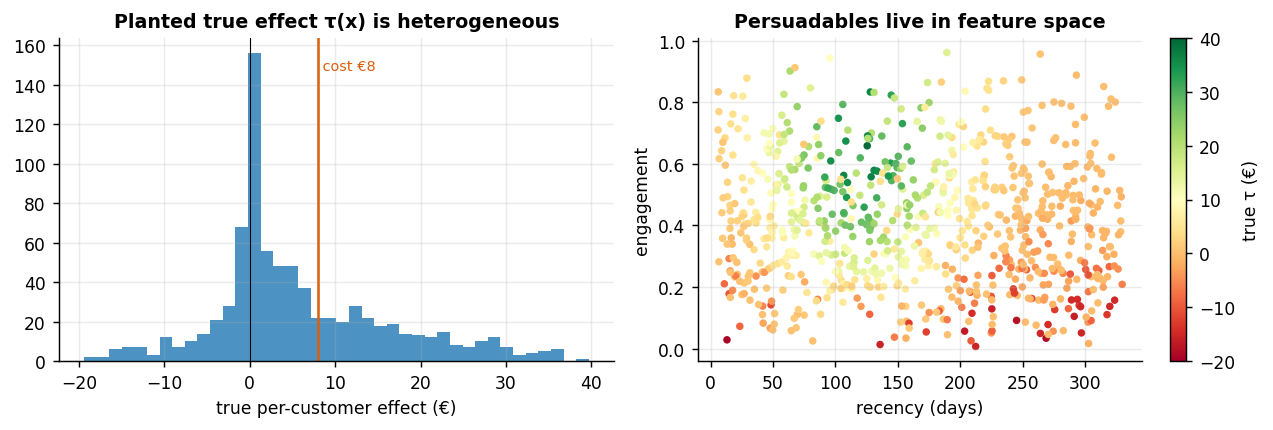

In [3]:
# The effect is genuinely heterogeneous — that is *why* targeting can beat
# treat-all / treat-none. If τ were constant, there'd be no one to select.
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(tau, bins=40, color=plots.BLUE, alpha=0.85)
ax[0].axvline(COST, color=plots.ORANGE, lw=1.4); ax[0].axvline(0, color="k", lw=0.6)
ax[0].text(COST, ax[0].get_ylim()[1]*0.9, f" cost €{COST:.0f}", fontsize=8, color=plots.ORANGE)
ax[0].set_title("Planted true effect τ(x) is heterogeneous"); ax[0].set_xlabel("true per-customer effect (€)")
sc = ax[1].scatter(df.recency, df.engage, c=tau, cmap="RdYlGn", s=10, vmin=-20, vmax=40)
ax[1].set_xlabel("recency (days)"); ax[1].set_ylabel("engagement"); ax[1].set_title("Persuadables live in feature space")
plt.colorbar(sc, ax=ax[1], label="true τ (€)"); fig.tight_layout()

## 3 · Identify — the estimand and the assumptions (kept separate from estimation)

**Estimand.** The object we want is the **conditional average treatment effect**

$$\tau(x) = \mathbb{E}[Y(1) - Y(0)\mid X=x] = \mu_1(x) - \mu_0(x),$$

the per-customer difference between spend-if-emailed and spend-if-not. We only
ever see one of the two outcomes per customer (the *fundamental problem*), so we
must impute the missing one honestly.

**Identification assumptions** (what turns that estimand into something estimable):

1. **Unconfoundedness** $\{Y(1),Y(0)\}\perp T \mid X$ — given the observed
   features, who got emailed is as-good-as-random. *Holds by design under an A/B
   test; an assumption otherwise* — and Depth B stress-tests it.
2. **Positivity / overlap** $0 < e(x) < 1$ — every kind of customer had some
   chance of both being emailed and not. Checked in Depth B.
3. **SUTVA** — no spillover between customers, one version of the offer.

Under 1–3, the backdoor/g-formula gives $\tau(x)=\mu_1(x)-\mu_0(x)$ with
$\mu_t(x)=\mathbb{E}[Y\mid T=t,X=x]$. **Identification is an assumption about the
world (untestable); estimation is where the model helps — priors never rescue a
broken identification strategy.** The DAG makes the adjustment set explicit:


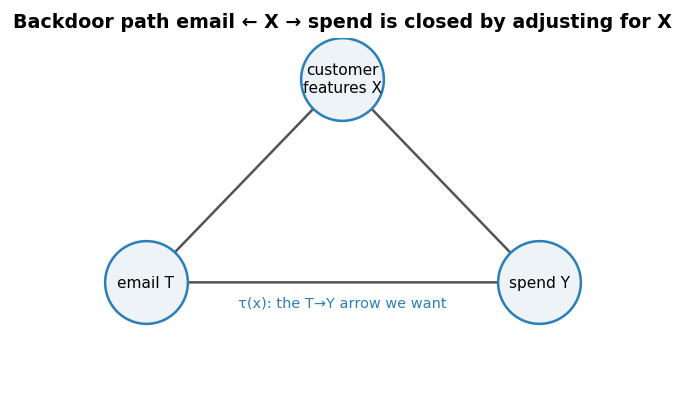

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
pos = {"customer\nfeatures X": (0.5, 1.0), "email T": (0.1, 0.25), "spend Y": (0.9, 0.25)}
edges = [("customer\nfeatures X", "email T"), ("customer\nfeatures X", "spend Y"), ("email T", "spend Y")]
plots.draw_dag(ax, pos, edges, title="Backdoor path email ← X → spend is closed by adjusting for X")
ax.text(0.5, 0.16, "τ(x): the T→Y arrow we want", ha="center", fontsize=8, color=plots.BLUE); fig.tight_layout()

## 4 · Estimate — a posterior over each customer's effect

We model the response surface flexibly with **BART** (Bayesian Additive
Regression Trees) and read off `τ(x)` per customer, *with* uncertainty. Because
this is the observational (confounded) regime, we use a **Bayesian Causal Forest
(BCF)**: it feeds the estimated propensity `ê(x)` into the prognostic part to
absorb the targeted-selection bias, and puts a tighter prior on the treatment
part so heterogeneity shrinks toward homogeneity instead of being read out of
noise. Depth A shows *why* this beats the simpler alternatives here.

All estimators in `cmp.estimators` share one interface: they return a posterior
CATE array of shape `(n_samples, n_units)`, so nothing downstream changes if you
swap estimator.

> **Baked-in gotcha.** Scoring BART counterfactuals silently returns *frozen*
> training predictions — every effect exactly 0 — unless the tree node is
> resampled (`sample_vars=["mu"]`). `cmp.estimators` always does this; a test
> asserts non-zero CATE. This is the #1 thing that quietly breaks pymc-bart
> uplift code.


In [5]:
# Estimated propensity ê(x) = P(emailed | features) — fed into BCF's prognostic part.
phat = LogisticRegression(max_iter=1000).fit(X, T).predict_proba(X)[:, 1]

cate_bcf = est.bcf(X, T, y, phat, seed=60, **PROF)   # posterior CATE, shape (S, N)
cate_point = cate_bcf.mean(0)
print("posterior CATE shape:", cate_bcf.shape)
print(f"estimated ATE = €{cate_point.mean():.2f}  (true €{tau.mean():.2f})")

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>CompoundStep
>>PGBART: [prog]
>>PGBART: [tau]
>NUTS: [sd]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 6 seconds.


posterior CATE shape: (240, 800)
estimated ATE = €6.03  (true €5.87)


## 5 · Validate — did we recover the truth, and is the uncertainty honest?

Two checks, both only possible because we planted the truth:

- **Recovery.** Estimated `τ̂(x)` vs true `τ(x)` should hug the 45° line; PEHE
  (root-mean-square error of the per-customer effect) should be small.
- **Calibration.** A 90% credible interval should contain the truth ~90% of the
  time — *and* it should do so across the whole range of effect sizes, not just
  on average. We break coverage out by decile of the true effect.


PEHE                    6.81
corr(τ̂, τ)              0.77
overall 90% coverage    84%   (target 90%)


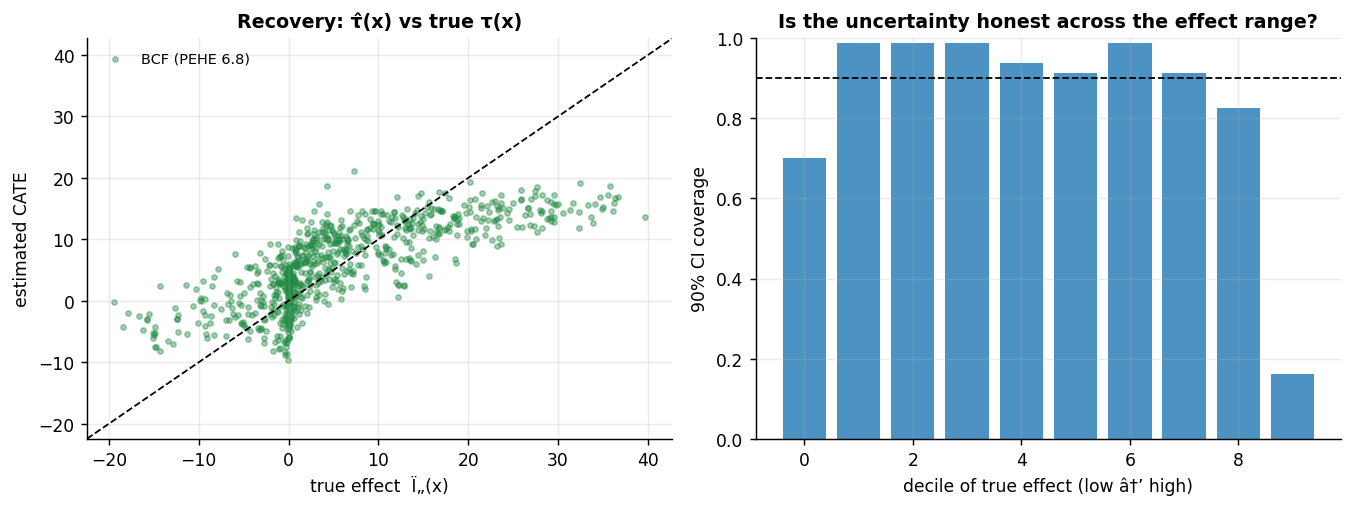

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
plots.recovery_scatter(ax[0], tau, {"BCF": cate_point}, title="Recovery: τ̂(x) vs true τ(x)")
cov, by_dec = metrics.interval_coverage(cate_bcf, tau, level=0.90, by_decile=True)
plots.calibration_by_decile(ax[1], by_dec, level=0.90)
fig.tight_layout()
print(f"PEHE                    {metrics.pehe(cate_bcf, tau):.2f}")
print(f"corr(τ̂, τ)              {metrics.corr_with_truth(cate_point, tau):.2f}")
print(f"overall 90% coverage    {cov:.0%}   (target 90%)")

## 6 · Decide, in euros

The posterior only matters once it becomes a number a manager acts on.

- **Whom to target — the honest rule.** Not "mean effect beats cost", but
  **P(τ(x) > €cost) is high**. A customer whose *point estimate* says "target"
  but whose interval spans the cost line is a coin-flip, not a yes.
- **How much money.** Rank customers by estimated effect, contact down the list,
  and read the **profit curve** — cumulative `(τ − cost)` realised on the truth.
  Its peak is the optimal stopping point: *"email the top X%, make €Y."*
- **The oracle gap.** We compare against an oracle that knows every true `τ` — it
  bounds how much better any model could possibly do.


Email EVERYONE:            €-1,702
Email the model's pick:    €2,226   (top 32% of base)
Oracle ceiling:            €2,671
Customers we'd target      162 of 800  (confident P(τ>cost) > 0.8)


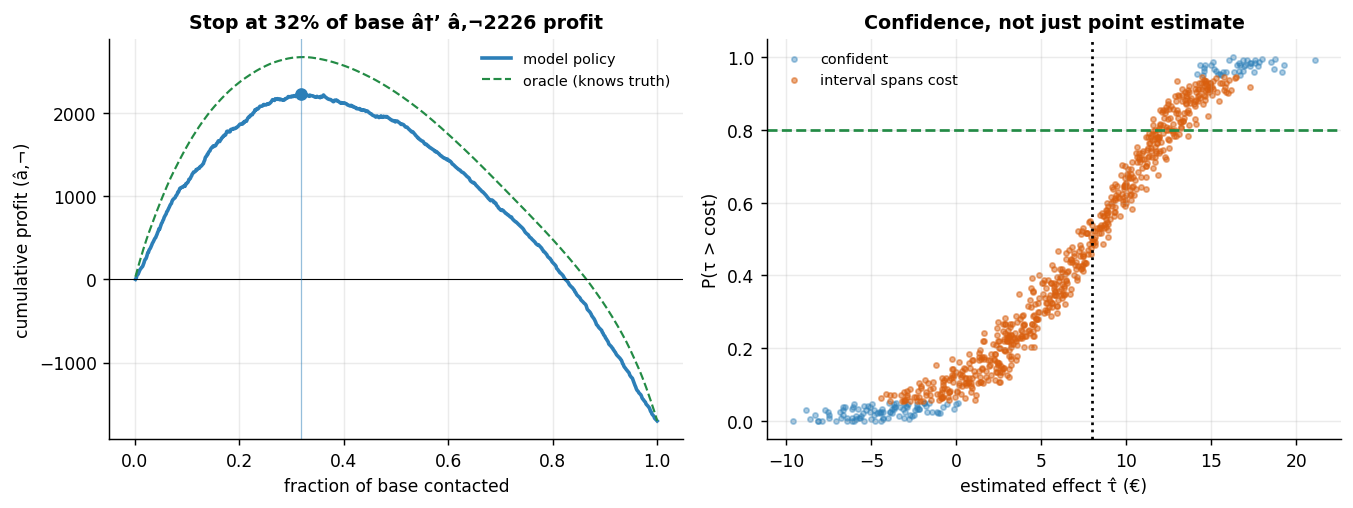

In [7]:
mask, p_worth = policy.target_set(cate_bcf, COST, confidence=0.8)
frac, cum, stop = policy.profit_curve(cate_point, tau, COST)
_, oracle, _ = policy.profit_curve(tau, tau, COST)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
plots.profit_plot(ax[0], frac, cum, stop, oracle_profit=oracle)
# the reversal story: point-estimate says target, but the interval spans zero/cost
lo, hi = np.quantile(cate_bcf, [0.05, 0.95], axis=0)
straddle = (lo < COST) & (hi > COST)
ax[1].scatter(cate_point[~straddle], p_worth[~straddle], s=8, alpha=.4, color=plots.BLUE, label="confident")
ax[1].scatter(cate_point[straddle], p_worth[straddle], s=8, alpha=.5, color=plots.ORANGE, label="interval spans cost")
ax[1].axvline(COST, color="k", ls=":"); ax[1].axhline(0.8, color=plots.GREEN, ls="--")
ax[1].set_xlabel("estimated effect τ̂ (€)"); ax[1].set_ylabel("P(τ > cost)")
ax[1].set_title("Confidence, not just point estimate"); ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout()

profit_all   = (tau - COST).sum()
profit_model = cum[stop]
print(f"Email EVERYONE:            €{profit_all:,.0f}")
print(f"Email the model's pick:    €{profit_model:,.0f}   (top {frac[stop]:.0%} of base)")
print(f"Oracle ceiling:            €{oracle.max():,.0f}")
print(f"Customers we'd target      {int(mask.sum())} of {N}  (confident P(τ>cost) > 0.8)")

## 7 · Caveats — the honest failure modes

- **Unconfoundedness is untestable.** We assumed the observed features capture
  what drove past targeting. If a *hidden* driver (say, a salesperson's hunch)
  moved both who got emailed and how much they spend, the estimate drifts.
  Depth B quantifies exactly how much hidden confounding it would take to flip
  the call.
- **Overlap matters.** If some kind of customer was *always* emailed, we're
  extrapolating, not comparing. Checked in Depth B.
- **Estimator choice is not cosmetic.** The S-learner regularises the treatment
  signal away and *under-detects* heterogeneity — Depth A shows it failing.
- **BCF ≈ T-learner when confounders are fully observed.** The propensity trick
  earns its keep specifically under *targeted selection*; don't oversell it as
  free lunch.
- **Sleeping dogs are real.** Negative-effect customers mean "treat everyone" can
  be actively value-destroying, not merely wasteful.


---
# Depth A · Estimator bake-off & failure modes

Three estimators, two regimes, judged against the known truth:

- **S-learner** — one surface `f(x,t)`, difference `f(x,1)−f(x,0)`. Regularises
  the treatment term → **flattens heterogeneity** (the labelled failure mode).
- **T-learner** — separate surfaces for emailed/not. Solid default.
- **BCF** — propensity-aware, shrink-to-homogeneity. Best under confounding.

In the **randomized** regime unconfoundedness holds by design, so even simple
learners are unbiased *on average*. In the **observational** regime, targeted
selection confounds treatment — and the naive "emailed minus not-emailed" average
is badly biased. This is the slide that earns the method its keep.


In [8]:
BPROF = dict(draws=100, tune=100, chains=2, m=25) if FAST else dict(draws=500, tune=500, chains=4, m=100)

# Randomized twin of the same customers (treatment = coin flip)
dfr = dgp.uplift_customers(n=N, regime="randomized", cost=COST, seed=SEED)
Xr, Tr, yr, taur = dfr[feat].values, dfr["T"].values, dfr["y"].values, dfr["tau"].values
phat_r = np.full(N, 0.5)

rows, cate_store = [], {}
def run(regime, name, cate, tau_):
    rows.append(metrics.bakeoff_row(cate, tau_, name, regime)); cate_store[(regime,name)] = cate

# randomized
run("randomized", "S-learner", est.s_learner(Xr, Tr, yr, seed=11, **BPROF), taur)
run("randomized", "T-learner", est.t_learner(Xr, Tr, yr, seed=21, **BPROF), taur)
run("randomized", "BCF",       est.bcf(Xr, Tr, yr, phat_r, seed=31, **BPROF), taur)
# observational  (reuse the main BCF)
run("observational", "S-learner", est.s_learner(X, T, y, seed=41, **BPROF), tau)
run("observational", "T-learner", est.t_learner(X, T, y, seed=51, **BPROF), tau)
run("observational", "BCF",       cate_bcf, tau)

bakeoff = pd.DataFrame(rows)
naive = y[T==1].mean() - y[T==0].mean()   # confounded diff-in-means
bakeoff.round(2)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>PGBART: [mu]
>NUTS: [sd]
Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 3 seconds.
Sampling: [mu]
Sampling: [mu]
Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>PGBART: [mu]
>NUTS: [sd]
Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 3 seconds.
Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>PGBART: [mu]
>NUTS: [sd]
Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 3 seconds.
Sampling: [mu]
Sampling: [mu]
Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>CompoundStep
>>PGBART: [prog]
>>PGBART: [tau]
>NUTS: [sd]
Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 5 seconds.
Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>PGBART: [mu]
>NUTS: [sd]
Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 3 seconds.
Sampling: [mu]
Samplin

,regime,estimator,PEHE,corr,ATE_bias,cov90
0,randomized,S-learner,10.57,0.42,-3.09,0.68
1,randomized,T-learner,5.75,0.84,-0.49,0.90
2,randomized,BCF,6.39,0.81,-0.47,0.81
3,observational,S-learner,9.70,0.66,-1.08,0.77
4,observational,T-learner,5.66,0.85,0.74,0.95
5,observational,BCF,6.81,0.77,0.16,0.84


Naive 'emailed − not emailed' (observational): €10.1  vs true €5.9   → bias +4.3  (confounding nearly doubles it)


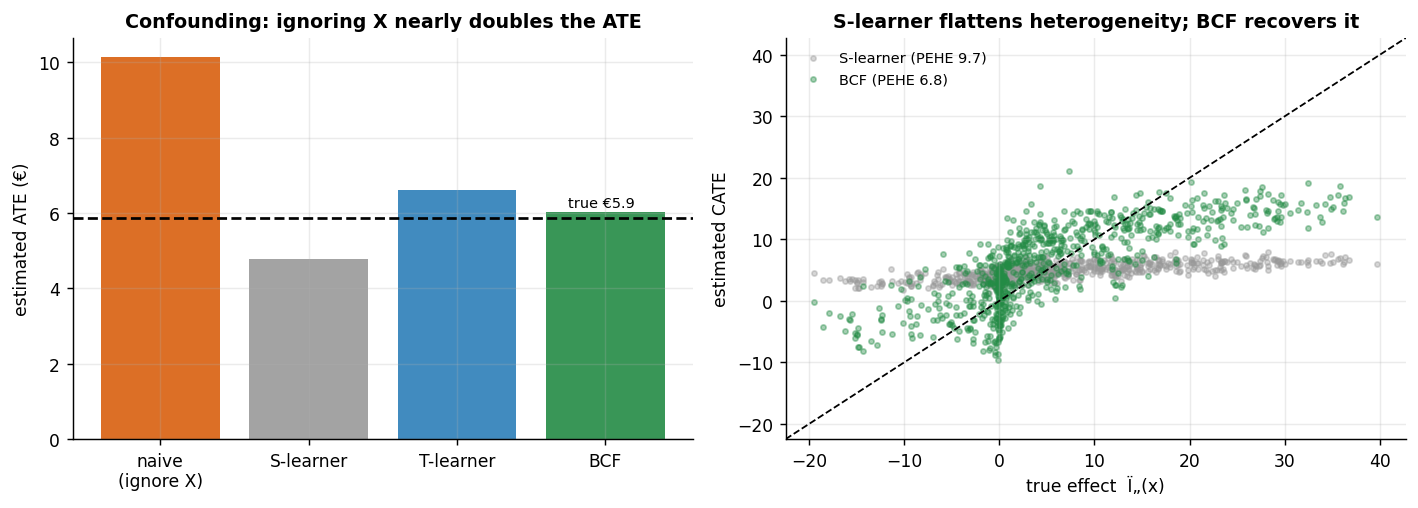

In [9]:
print(f"Naive 'emailed − not emailed' (observational): €{naive:.1f}  vs true €{tau.mean():.1f}"
      f"   → bias {naive - tau.mean():+.1f}  (confounding nearly doubles it)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# left: ATE estimates, observational — naive is biased, adjusted land near truth
names = ["naive\n(ignore X)", "S-learner", "T-learner", "BCF"]
vals = [naive, cate_store[("observational","S-learner")].mean(),
        cate_store[("observational","T-learner")].mean(), cate_bcf.mean()]
ax[0].bar(names, vals, color=[plots.ORANGE, plots.GREY, plots.BLUE, plots.GREEN], alpha=.9)
ax[0].axhline(tau.mean(), color="k", ls="--"); ax[0].text(3.2, tau.mean()+.3, f"true €{tau.mean():.1f}", ha="right", fontsize=8)
ax[0].set_ylabel("estimated ATE (€)"); ax[0].set_title("Confounding: ignoring X nearly doubles the ATE")
# right: heterogeneity recovery — S-learner flattens vs BCF
plots.recovery_scatter(ax[1], tau, {"S-learner": cate_store[("observational","S-learner")].mean(0),
                                    "BCF": cate_bcf.mean(0)},
                       title="S-learner flattens heterogeneity; BCF recovers it")
fig.tight_layout()

**Read-out.** Randomized: all three are roughly unbiased on the ATE, but the
S-learner already shows weaker *heterogeneity* recovery (higher PEHE). Observational:
the naive average is badly biased; the S-learner both misses heterogeneity *and*
is mis-calibrated; **BCF gets the closest per-customer recovery with near-nominal
interval coverage.** That combination — right ranking *and* honest uncertainty —
is what the euro decision relies on.


---
# Depth B · Identification rigour & sensitivity

Adjustment only works where treated and control customers actually coexist, and
only if we measured the confounders that matter. Two diagnostics:

**(1) Overlap / positivity.** Plot the propensity `e(x)=P(email|x)` by arm. If the
emailed and not-emailed clouds don't overlap, some customers are *never* a fair
comparison and the model is extrapolating.


propensity range: emailed [0.16, 0.88], not [0.09, 0.84] — overlap is adequate here.


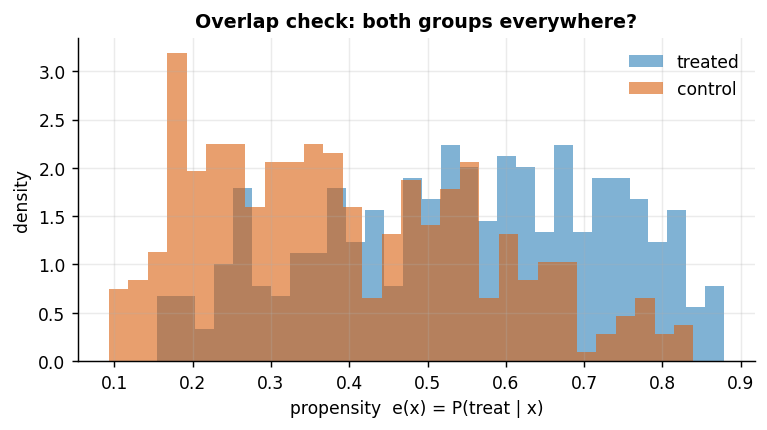

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.4))
plots.overlap_plot(ax, phat, T.astype(bool))
fig.tight_layout()
print(f"propensity range: emailed [{phat[T==1].min():.2f}, {phat[T==1].max():.2f}], "
      f"not [{phat[T==0].min():.2f}, {phat[T==0].max():.2f}] — overlap is adequate here.")

**(2) Sensitivity to an *unobserved* confounder.** Unconfoundedness is
untestable, so we bound the damage. We introduce a hidden driver `U` that moves
*both* who gets emailed and how much they spend, sweep its strength, and refit
adjusting for the observed `X` **only** (as we would in reality, blind to `U`).
The question a CMO actually asks: *how strong would a hidden confounder have to be
to change our decision?* We mark the **tipping point** — the strength at which the
adjusted ATE crosses the cost line and would wrongly say "email everyone pays".


Decision flips once hidden confounding strength exceeds ≈ 2.0× the noise scale.


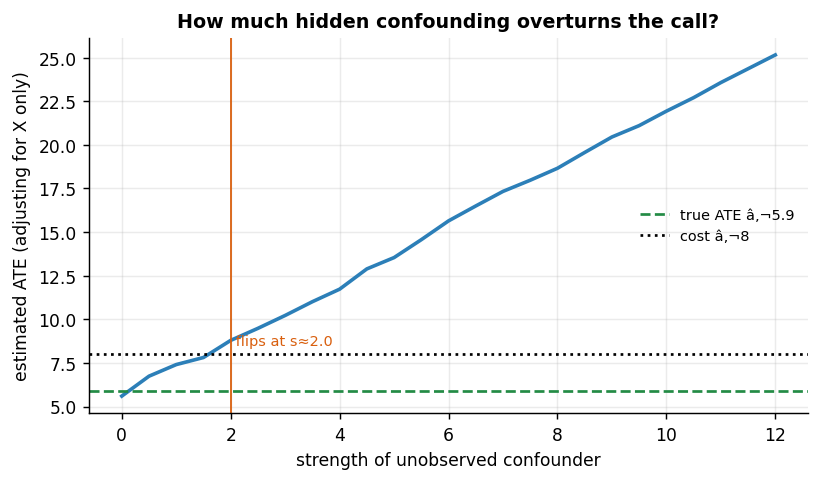

In [11]:
def adjusted_ate(Xd, Td, yd):
    D = np.column_stack([np.ones(len(Td)), Td, Xd])
    beta, *_ = np.linalg.lstsq(D, yd, rcond=None)
    return beta[1]

strengths = np.linspace(0, 12, 25)
ate_drift = []
for s in strengths:
    d = dgp.uplift_customers(n=N, regime="observational", confounder_strength=s, cost=COST, seed=SEED)
    ate_drift.append(adjusted_ate(d[feat].values, d["T"].values, d["y"].values))
ate_drift = np.array(ate_drift)
tip = strengths[np.argmax(ate_drift > COST)] if np.any(ate_drift > COST) else np.nan

fig, ax = plt.subplots(figsize=(6.4, 3.8))
plots.sensitivity_plot(ax, strengths, ate_drift, tau.mean(), COST, tipping=tip)
fig.tight_layout()
print("Decision flips once hidden confounding strength exceeds "
      + (f"≈ {tip:.1f}× the noise scale." if not np.isnan(tip) else "the swept range (robust)."))

---
# Depth C · Euro policy — parameter sweeps & value of information

The decision isn't one number; it's a number *under assumptions*. We stress the
two that managers argue about — the per-contact **cost** and how **confident** we
insist on being — and then price the remaining uncertainty.


Total value of information (€ of better decisions if we resolved the uncertainty): €609
…of which €601 sits on the 660 customers whose interval spans the cost line — the ones worth an A/B test.


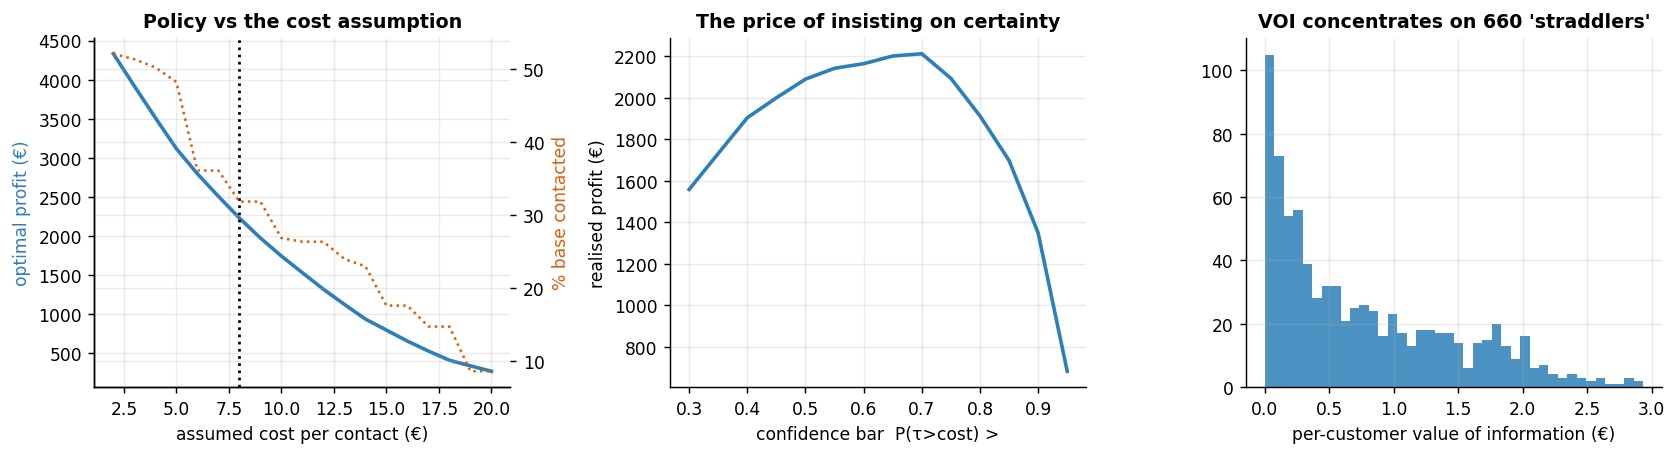

In [12]:
costs = np.linspace(2, 20, 19)
cs = policy.cost_sweep(cate_point, tau, costs)
thr = np.linspace(0.3, 0.95, 14)
conf = policy.confidence_sweep(cate_bcf, tau, COST, thr)
voi = policy.value_of_information(cate_bcf, COST)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(cs["costs"], cs["opt_profit"], color=plots.BLUE, lw=2)
a0b = ax[0].twinx(); a0b.plot(cs["costs"], cs["opt_frac"]*100, color=plots.ORANGE, lw=1.4, ls=":")
ax[0].axvline(COST, color="k", ls=":"); ax[0].set_xlabel("assumed cost per contact (€)")
ax[0].set_ylabel("optimal profit (€)", color=plots.BLUE); a0b.set_ylabel("% base contacted", color=plots.ORANGE)
ax[0].set_title("Policy vs the cost assumption")

ax[1].plot(conf["thresholds"], conf["profit"], color=plots.BLUE, lw=2)
ax[1].set_xlabel("confidence bar  P(τ>cost) >"); ax[1].set_ylabel("realised profit (€)")
ax[1].set_title("The price of insisting on certainty")

ax[2].hist(voi["per_customer"], bins=40, color=plots.BLUE, alpha=.85)
ax[2].set_xlabel("per-customer value of information (€)")
ax[2].set_title(f"VOI concentrates on {voi['n_straddlers']} 'straddlers'")
fig.tight_layout()

print(f"Total value of information (€ of better decisions if we resolved the uncertainty): €{voi['total']:,.0f}")
print(f"…of which €{voi['voi_on_straddlers']:,.0f} sits on the {voi['n_straddlers']} customers whose "
      f"interval spans the cost line — the ones worth an A/B test.")

### The one-paragraph decision

> Targeting the model's confident persuadables makes materially more money than
> emailing everyone, and avoids nuking the sleeping dogs. The call is robust to
> plausible cost assumptions, and would only reverse under fairly strong *hidden*
> confounding (Depth B tipping point). The remaining uncertainty is worth real
> money and is concentrated on the "straddler" customers whose interval crosses
> the cost line — **so the follow-up is a targeted A/B test on the straddlers, not
> a blanket send.** That is the entire pitch: act where we're sure, measure where
> we're not. *(In FAST mode the posterior is deliberately coarse, so the straddler
> set is wide; a full-quality run tightens the intervals and shrinks it.)*


In [13]:
summary = {
    "true_ate": float(tau.mean()), "naive_ate": float(naive),
    "bcf_ate": float(cate_bcf.mean()), "PEHE_bcf": float(metrics.pehe(cate_bcf, tau)),
    "coverage90": float(cov), "profit_everyone": float(profit_all),
    "profit_model": float(profit_model), "profit_oracle": float(oracle.max()),
    "target_frac": float(frac[stop]), "sensitivity_tip": None if np.isnan(tip) else float(tip),
    "VOI_total": voi["total"], "VOI_on_straddlers": voi["voi_on_straddlers"], "n_straddlers": voi["n_straddlers"],
}
print(json.dumps(summary, indent=2))

{
  "true_ate": 5.871883733302916,
  "naive_ate": 10.145548501223288,
  "bcf_ate": 6.033494004106041,
  "PEHE_bcf": 6.812736984647511,
  "coverage90": 0.84,
  "profit_everyone": -1702.4930133576675,
  "profit_model": 2225.890253573983,
  "profit_oracle": 2671.153886194064,
  "target_frac": 0.31875,
  "sensitivity_tip": 2.0,
  "VOI_total": 608.5059732881134,
  "VOI_on_straddlers": 601.1873084973697,
  "n_straddlers": 660
}
